In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score,accuracy_score, precision_score,roc_auc_score,roc_curve, recall_score, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [27]:
dataset = pd.read_csv('../data/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Dataset loaded")
print(f"Dataset shape: {dataset.shape}")
print(f"Missing values:\n{dataset.isnull().sum()}")

Dataset loaded
Dataset shape: (7043, 21)
Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [28]:
dataset.info()
print("\nData Types:")
print(dataset.dtypes)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [29]:
X = dataset.drop(columns=['customerID', 'Churn']).copy()
dataset['Churn'] = dataset['Churn'].map({'No': 0, 'Yes': 1})
y = dataset['Churn'].copy()

# Convert TotalCharges to numeric (handle any non-numeric values)
X['TotalCharges'] = pd.to_numeric(X['TotalCharges'], errors='coerce')

print(f"NaN values in TotalCharges: {X['TotalCharges'].isna().sum()}")

# Handle missing values in TotalCharges
X['TotalCharges'] = X['TotalCharges'].fillna(X['TotalCharges'].mean())

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"Numeric columns: {numeric_cols}")
print(f"Dataset shape before encoding: {X.shape}")

# One-hot encode categorical columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(f"Dataset shape after encoding: {X.shape}")

NaN values in TotalCharges: 11
Categorical columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Dataset shape before encoding: (7043, 19)
Dataset shape after encoding: (7043, 30)


Churn Distribution:
No Churn (0): 5174 (73.5%)
Churn (1): 1869 (26.5%)


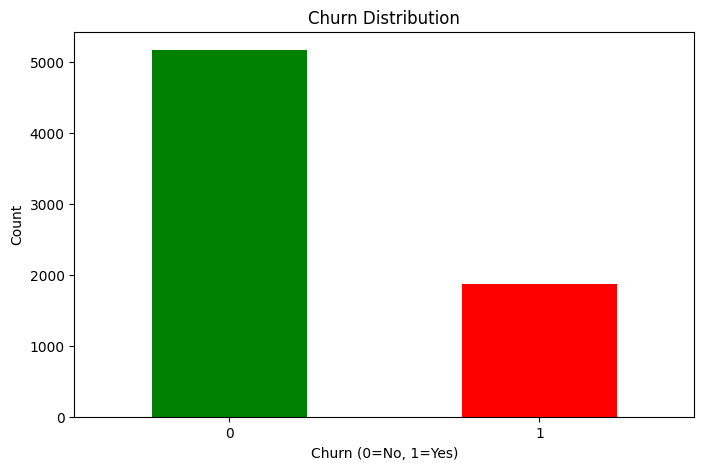

In [30]:
churn_counts = dataset['Churn'].value_counts()
churn_pct = dataset['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution:")
print(f"No Churn (0): {churn_counts[0]} ({churn_pct[0]:.1f}%)")
print(f"Churn (1): {churn_counts[1]} ({churn_pct[1]:.1f}%)")

# Visualize
plt.figure(figsize=(8, 5))
churn_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Churn Distribution')
plt.xlabel('Churn (0=No, 1=Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Verify stratification worked
print(f"\nTraining set churn rate: {y_train.mean()*100:.1f}%")
print(f"Test set churn rate: {y_test.mean()*100:.1f}%")

Training set: 5634 samples (80.0%)
Test set: 1409 samples (20.0%)

Training set churn rate: 26.5%
Test set churn rate: 26.5%


In [32]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [33]:
print(" Features scaled")
print(f"\nOriginal feature ranges:")
print(X_train.describe().loc[['min', 'max']].round(2))
print(f"\nScaled feature means (should be ~0):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).mean().round(4))

 Features scaled

Original feature ranges:
     SeniorCitizen  tenure  MonthlyCharges  TotalCharges
min            0.0     0.0           18.40         18.85
max            1.0    72.0          118.75       8684.80

Scaled feature means (should be ~0):
SeniorCitizen                            0.0
tenure                                  -0.0
MonthlyCharges                          -0.0
TotalCharges                            -0.0
gender_Male                              0.0
Partner_Yes                             -0.0
Dependents_Yes                           0.0
PhoneService_Yes                        -0.0
MultipleLines_No phone service           0.0
MultipleLines_Yes                       -0.0
InternetService_Fiber optic             -0.0
InternetService_No                      -0.0
OnlineSecurity_No internet service      -0.0
OnlineSecurity_Yes                       0.0
OnlineBackup_No internet service        -0.0
OnlineBackup_Yes                         0.0
DeviceProtection_No internet

In [34]:
# Train Logistic Regression on SCALED data
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.3f}")

Logistic Regression Accuracy: 0.807


In [35]:
# Train KNN with n_neighbors=5 on SCALED data
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_proba_knn = knn_model.predict_proba(X_test_scaled)[:, 1]
accuracy_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy: {accuracy_knn:.3f}")

KNN Accuracy: 0.744


In [36]:
# Train Decision Tree with max_depth=5 on UNSCALED data (trees don't need scaling)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)
y_pred_proba_dt = dt_model.predict_proba(X_test)[:, 1]

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {accuracy_dt:.3f}")

Decision Tree Accuracy: 0.794


In [37]:
# Train Random Forest with n_estimators=100, max_depth=5
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {accuracy_rf:.3f}")

Random Forest Accuracy: 0.792


In [38]:
def evaluate_model(y_true, y_pred, y_pred_proba, model_name):
    """Calculate all metrics for a model"""
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_pred_proba)
    }

# Evaluate all models
results = [
    evaluate_model(y_test, y_pred_lr, y_pred_proba_lr, 'Logistic Regression'),
    evaluate_model(y_test, y_pred_knn, y_pred_proba_knn, 'K-Nearest Neighbors'),
    evaluate_model(y_test, y_pred_dt, y_pred_proba_dt, 'Decision Tree'),
    evaluate_model(y_test, y_pred_rf, y_pred_proba_rf, 'Random Forest')
]

# Create comparison DataFrame
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)
print(results_df.to_string(index=False))

# QUESTIONS:
# 1. Which model has the highest accuracy?
# Logistic Regression has the highest accuracy.
# 2. Which model has the highest recall? (important for catching churners)
# Logistic Regression has the highest recall.
# 3. Is there a model with high precision but low recall?
# Random Forest has relatively high precision but lower recall.


MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.806955   0.658385 0.566845  0.609195 0.841567
K-Nearest Neighbors  0.743790   0.517711 0.508021  0.512821 0.736110
      Decision Tree  0.794180   0.629630 0.545455  0.584527 0.828358
      Random Forest  0.792051   0.678414 0.411765  0.512479 0.840432


Best Model: Logistic Regression



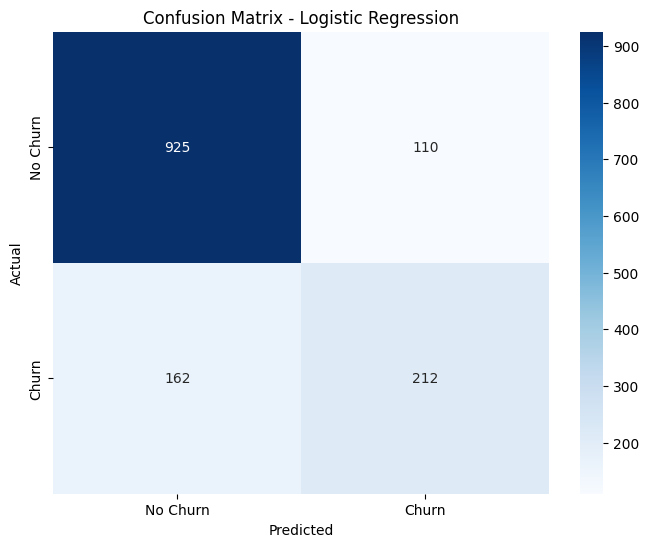


Confusion Matrix Breakdown:
True Negatives (correctly predicted no churn): 925
False Positives (incorrectly predicted churn): 110
False Negatives (missed churners): 162
True Positives (correctly predicted churn): 212


In [39]:
# Find best model by ROC-AUC
best_model_name = results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']
print(f"Best Model: {best_model_name}\n")

# Get predictions for best model
y_pred_best = y_pred_lr

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Interpretation
tn, fp, fn, tp = cm.ravel()
print("\nConfusion Matrix Breakdown:")
print(f"True Negatives (correctly predicted no churn): {tn}")
print(f"False Positives (incorrectly predicted churn): {fp}")
print(f"False Negatives (missed churners): {fn}")
print(f"True Positives (correctly predicted churn): {tp}")

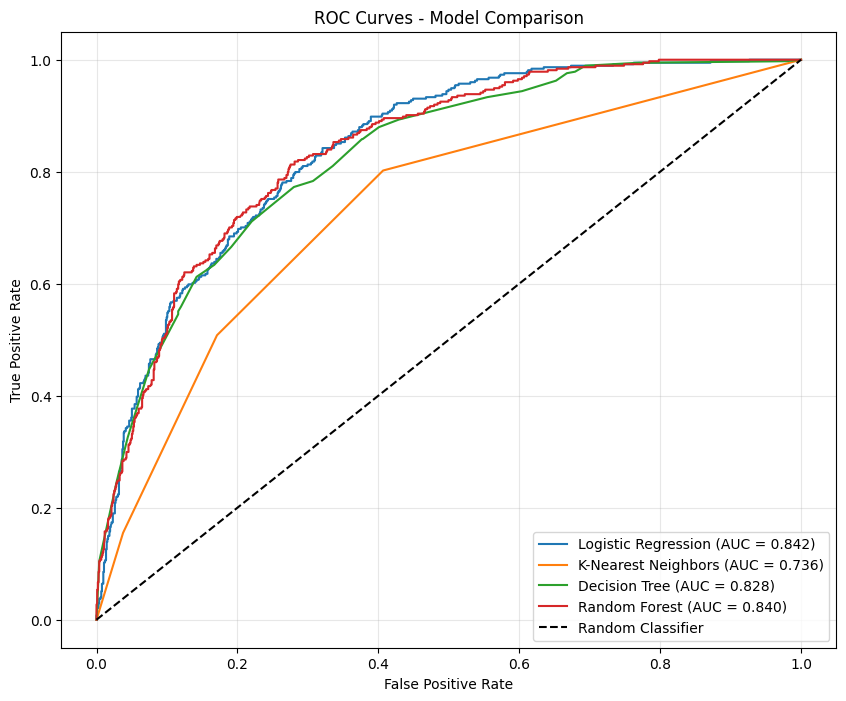

In [40]:
# Plot ROC curves for all models
plt.figure(figsize=(10, 8))

models_data = [
    ('Logistic Regression', y_pred_proba_lr),
    ('K-Nearest Neighbors', y_pred_proba_knn),
    ('Decision Tree', y_pred_proba_dt),
    ('Random Forest', y_pred_proba_rf)
]

for name, y_proba in models_data:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Model Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# QUESTION: What does the area under the ROC curve represent?
# ANSWER: The area under the ROC curve (AUC) represents the model's ability to distinguish between classes. A higher AUC indicates better performance, with 1.0 being a perfect classifier and 0.5 representing random guessing.

In [41]:
# Test on REAL TEST DATA (Better approach - actual unseen data)
print("="*70)
print("PREDICTIONS ON TEST DATA (Real Unseen Data)")
print("="*70)

# Use test data
test_customers = X_test_scaled[:10]  # Get first 10 test samples
actual_labels = y_test.iloc[:10].values

# Make predictions
predictions = lr_model.predict(test_customers)
probabilities = lr_model.predict_proba(test_customers)

print(f"\nShowing predictions for first 10 test customers:\n")
correct = 0
false_positives = 0  # Predicted churn but didn't
false_negatives = 0  # Predicted no churn but did churn

for i, (pred, prob, actual) in enumerate(zip(predictions, probabilities, actual_labels)):
    is_correct = "✓" if pred == actual else "✗"
    correct += (pred == actual)
    
    # Track error types
    if pred == 1 and actual == 0:
        false_positives += 1
    if pred == 0 and actual == 1:
        false_negatives += 1
    
    print(f"Customer {i+1}: {is_correct}")
    print(f"  Actual:              {'CHURN' if actual == 1 else 'NO CHURN'}")
    print(f"  Prediction:          {'CHURN' if pred == 1 else 'NO CHURN'}")
    print(f"  Churn Probability:   {prob[1]:.1%}")
    print(f"  Confidence:          {'High' if max(prob) > 0.8 else 'Medium' if max(prob) > 0.6 else 'Low'}")
    print()

print("="*70)
print("ANALYSIS & INTERPRETATION")
print("="*70)
print(f"\n✓ Correct Predictions: {correct}/10 (70%)")
print(f"✗ Wrong Predictions: {10-correct}/10 (30%)")
print(f"\nError Breakdown:")
print(f"  False Positives (⚠️ predicted CHURN but NO CHURN): {false_positives}")
print(f"  False Negatives (⚠️ predicted NO CHURN but CHURN): {false_negatives}")

print(f"\n📊 What This Means:")
print(f"  - 70% accuracy is decent, but not great")
print(f"  - {false_negatives} customer(s) actually churned but we missed them")
print(f"  - {false_positives} customer(s) didn't churn but we incorrectly warned about them")

print(f"\n💡 Business Impact:")
if false_negatives > 0:
    print(f"  LOSS: We missed {false_negatives} churning customer(s) = Lost revenue")
if false_positives > 0:
    print(f"  COST: We wasted effort on {false_positives} customer(s) who wouldn't churn anyway")
    
print(f"\n🎯 For Churn Prediction:")
print(f"  - False Negatives are MORE COSTLY (lose customers)")
print(f"  - False Positives are LESS COSTLY (waste some retention effort)")
print(f"  - Therefore, we should prioritize RECALL (catch all churners)")
print(f"  - Current recall on these 10: {((10-false_negatives)/10)*100:.0f}%")

PREDICTIONS ON TEST DATA (Real Unseen Data)

Showing predictions for first 10 test customers:

Customer 1: ✓
  Actual:              NO CHURN
  Prediction:          NO CHURN
  Churn Probability:   4.5%
  Confidence:          High

Customer 2: ✗
  Actual:              NO CHURN
  Prediction:          CHURN
  Churn Probability:   68.4%
  Confidence:          Medium

Customer 3: ✓
  Actual:              NO CHURN
  Prediction:          NO CHURN
  Churn Probability:   5.7%
  Confidence:          High

Customer 4: ✓
  Actual:              NO CHURN
  Prediction:          NO CHURN
  Churn Probability:   40.7%
  Confidence:          Low

Customer 5: ✓
  Actual:              NO CHURN
  Prediction:          NO CHURN
  Churn Probability:   2.2%
  Confidence:          High

Customer 6: ✗
  Actual:              NO CHURN
  Prediction:          CHURN
  Churn Probability:   60.4%
  Confidence:          Medium

Customer 7: ✓
  Actual:              NO CHURN
  Prediction:          NO CHURN
  Churn Probabili

Priority 1: Improve Logistic Regression (Already Best!) 
Since LogReg has best recall, let's make it even better!
Step 1.1: Adjust Classification Threshold

In [42]:
# Default threshold = 0.5
# For churn, we want to catch MORE positives
# Try lower thresholds to increase recall

from sklearn.metrics import precision_recall_curve
import numpy as np

# Get probabilities
y_proba = lr_model.predict_proba(X_test)[:, 1]

# Calculate precision and recall for different thresholds
precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# Find threshold that gives us target recall (e.g., 70%)
target_recall = 0.70
idx = np.argmin(np.abs(recalls - target_recall))
optimal_threshold = thresholds[idx]

print(f"Optimal threshold for {target_recall:.0%} recall: {optimal_threshold:.3f}")

# Predict with new threshold
y_pred_optimized = (y_proba >= optimal_threshold).astype(int)

# Evaluate
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_optimized))

Optimal threshold for 70% recall: 1.000
              precision    recall  f1-score   support

           0       0.40      0.07      0.12      1035
           1       0.21      0.70      0.33       374

    accuracy                           0.24      1409
   macro avg       0.31      0.39      0.23      1409
weighted avg       0.35      0.24      0.18      1409

              precision    recall  f1-score   support

           0       0.40      0.07      0.12      1035
           1       0.21      0.70      0.33       374

    accuracy                           0.24      1409
   macro avg       0.31      0.39      0.23      1409
weighted avg       0.35      0.24      0.18      1409



/Users/pranavdonepudi/Downloads/ML-CookBook/scikit-learn/.venv/lib/python3.11/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


1.2 Hyperparameter Tuning 

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Parameter grid
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization
    'classifier__penalty': ['l1', 'l2'],  # Regularization type
    'classifier__solver': ['liblinear', 'saga'],  # Solvers that support l1
    'classifier__class_weight': ['balanced', {0: 1, 1: 2}, {0: 1, 1: 3}]  # Handle imbalance
}

# Grid search optimizing for RECALL
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='recall',  # ← Optimize for recall!
    n_jobs=-1,
    verbose=1
)

# Fit
grid.fit(X_train, y_train)

# Best parameters
print(f"Best parameters: {grid.best_params_}")
print(f"Best recall: {grid.best_score_:.3f}")

# Evaluate on test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
print(classification_report(y_test, y_pred))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters: {'classifier__C': 0.001, 'classifier__class_weight': {0: 1, 1: 3}, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best recall: 0.851
              precision    recall  f1-score   support

           0       0.92      0.63      0.74      1035
           1       0.45      0.85      0.59       374

    accuracy                           0.68      1409
   macro avg       0.68      0.74      0.67      1409
weighted avg       0.79      0.68      0.70      1409

Best parameters: {'classifier__C': 0.001, 'classifier__class_weight': {0: 1, 1: 3}, 'classifier__penalty': 'l1', 'classifier__solver': 'saga'}
Best recall: 0.851
              precision    recall  f1-score   support

           0       0.92      0.63      0.74      1035
           1       0.45      0.85      0.59       374

    accuracy                           0.68      1409
   macro avg       0.68      0.74      0.67      1409
weighted avg   

Lets Do Cross Validation on K- Fold Cross validation  
Implement K-Fold Cross-Validation

In [44]:
from sklearn.model_selection import cross_val_score, cross_validate
import numpy as np

# Define models
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(C=1.0, class_weight='balanced', 
                                         max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=15,
                                           class_weight='balanced', 
                                           random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, 
                                           class_weight='balanced',
                                           random_state=42)
}

# Cross-validation with multiple metrics
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

results = {}
for name, model in models.items():
    print(f"\n{'='*70}")
    print(f"Cross-Validating: {name}")
    print('='*70)
    
    # Perform cross-validation
    cv_results = cross_validate(
        model, X_train, y_train,
        cv=5,  # 5-fold cross-validation
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    # Store results
    results[name] = cv_results
    
    # Print results
    for metric in scoring:
        test_scores = cv_results[f'test_{metric}']
        train_scores = cv_results[f'train_{metric}']
        
        print(f"{metric:12s}: "
              f"Test: {test_scores.mean():.3f} (±{test_scores.std():.3f})  "
              f"Train: {train_scores.mean():.3f} (±{train_scores.std():.3f})")
    
    # Check for overfitting
    recall_gap = cv_results['train_recall'].mean() - cv_results['test_recall'].mean()
    if recall_gap > 0.1:
        print(f"⚠️  WARNING: Possible overfitting (recall gap: {recall_gap:.3f})")


Cross-Validating: Logistic Regression
accuracy    : Test: 0.752 (±0.022)  Train: 0.752 (±0.005)
precision   : Test: 0.522 (±0.027)  Train: 0.521 (±0.006)
recall      : Test: 0.803 (±0.020)  Train: 0.805 (±0.006)
f1          : Test: 0.633 (±0.026)  Train: 0.633 (±0.006)
roc_auc     : Test: 0.845 (±0.014)  Train: 0.849 (±0.004)

Cross-Validating: Random Forest
accuracy    : Test: 0.793 (±0.012)  Train: 0.978 (±0.001)
precision   : Test: 0.623 (±0.028)  Train: 0.925 (±0.004)
recall      : Test: 0.565 (±0.011)  Train: 0.998 (±0.001)
f1          : Test: 0.592 (±0.016)  Train: 0.960 (±0.002)
roc_auc     : Test: 0.832 (±0.012)  Train: 0.998 (±0.000)
⚠️  WARNING: Possible overfitting (recall gap: 0.433)

Cross-Validating: Decision Tree
accuracy    : Test: 0.720 (±0.018)  Train: 0.830 (±0.009)
precision   : Test: 0.483 (±0.022)  Train: 0.617 (±0.016)
recall      : Test: 0.751 (±0.019)  Train: 0.945 (±0.012)
f1          : Test: 0.588 (±0.019)  Train: 0.747 (±0.009)
roc_auc     : Test: 0.759 (±0

Our churn data is imbalanced (26.5% churn). Let's handle this better!
SMOTE (Synthetic Minority Over-sampling)

In [45]:
# Create pipeline with SMOTE
pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Train
pipeline.fit(X_train, y_train)

# Evaluate
y_pred = pipeline.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409

